In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées !")

✅ Bibliothèques importées !


In [2]:
# Chargement du dataset prétraité
df = pd.read_csv('../data/processed/diabetic_resampled.csv')

# Séparation X / y
X = df.drop(columns=['readmitted'])
y = df['readmitted']

# Split train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTrain : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

✅ Dataset chargé : 180818 lignes × 44 colonnes

Train : 144654 lignes
Test  : 36164 lignes


In [3]:
print("="*50)
print("ENTRAÎNEMENT DES MODÈLES")
print("="*50)

# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', n_jobs=-1)
}

# Entraînement et évaluation
results = {}
for name, model in models.items():
    print(f"\n⏳ Entraînement : {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {'model': model, 'y_pred': y_pred, 'auc': auc}
    print(f"✅ AUC-ROC : {auc:.4f}")

print("\n✅ Tous les modèles entraînés !")

ENTRAÎNEMENT DES MODÈLES

⏳ Entraînement : Logistic Regression...
✅ AUC-ROC : 0.7987

⏳ Entraînement : Random Forest...
✅ AUC-ROC : 0.9541

⏳ Entraînement : XGBoost...
✅ AUC-ROC : 0.9388

✅ Tous les modèles entraînés !


ÉVALUATION DÉTAILLÉE DES MODÈLES


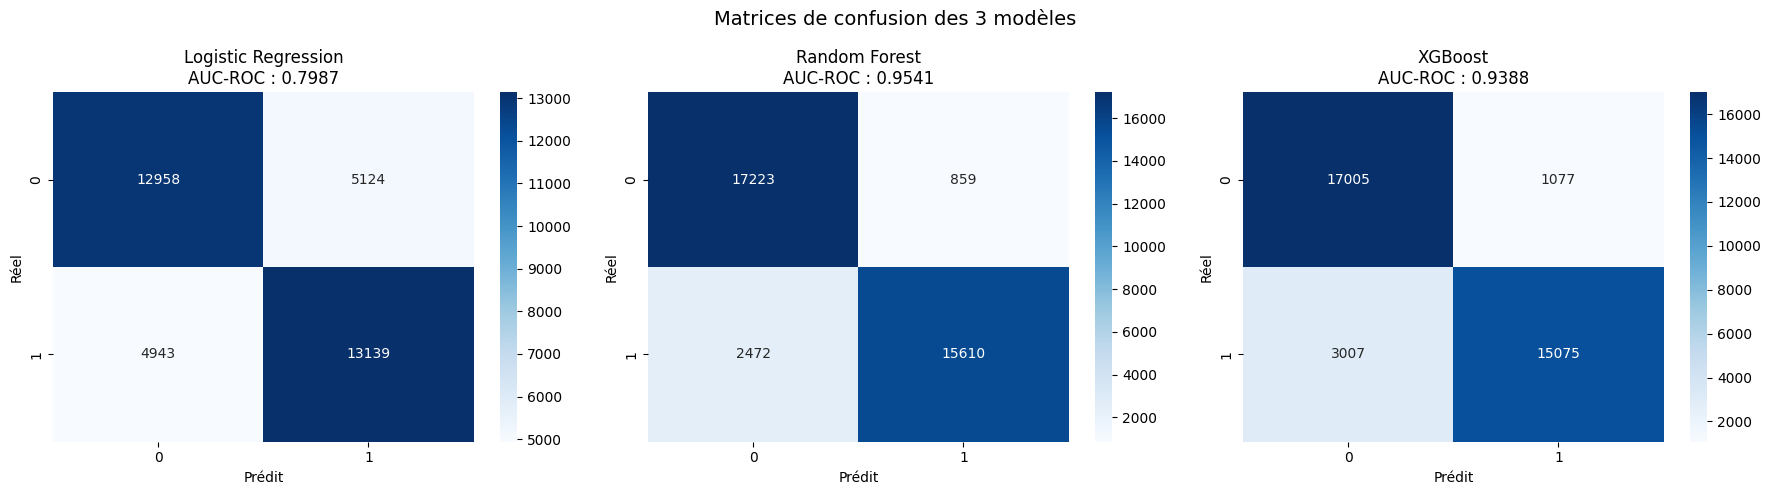


📊 Rapport détaillé — Random Forest :
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     18082
           1       0.95      0.86      0.90     18082

    accuracy                           0.91     36164
   macro avg       0.91      0.91      0.91     36164
weighted avg       0.91      0.91      0.91     36164



In [4]:
print("="*50)
print("ÉVALUATION DÉTAILLÉE DES MODÈLES")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nAUC-ROC : {res["auc"]:.4f}', fontsize=12)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion des 3 modèles', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150)
plt.show()

# Rapport de classification du meilleur modèle
print("\n📊 Rapport détaillé — Random Forest :")
print(classification_report(y_test, results['Random Forest']['y_pred']))

COURBES ROC


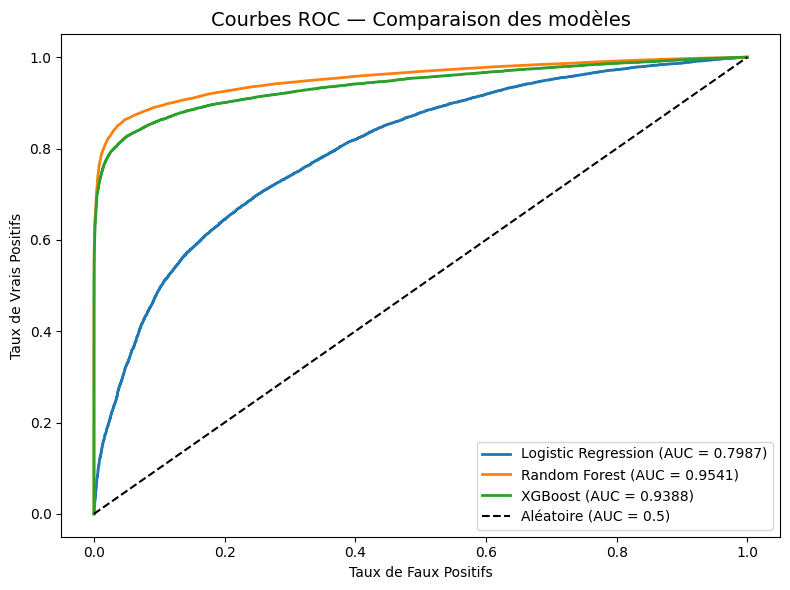

✅ Graphique sauvegardé !


In [5]:
print("="*50)
print("COURBES ROC")
print("="*50)

plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['model'].predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC — Comparaison des modèles', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé !")

IMPORTANCE DES FEATURES — RANDOM FOREST


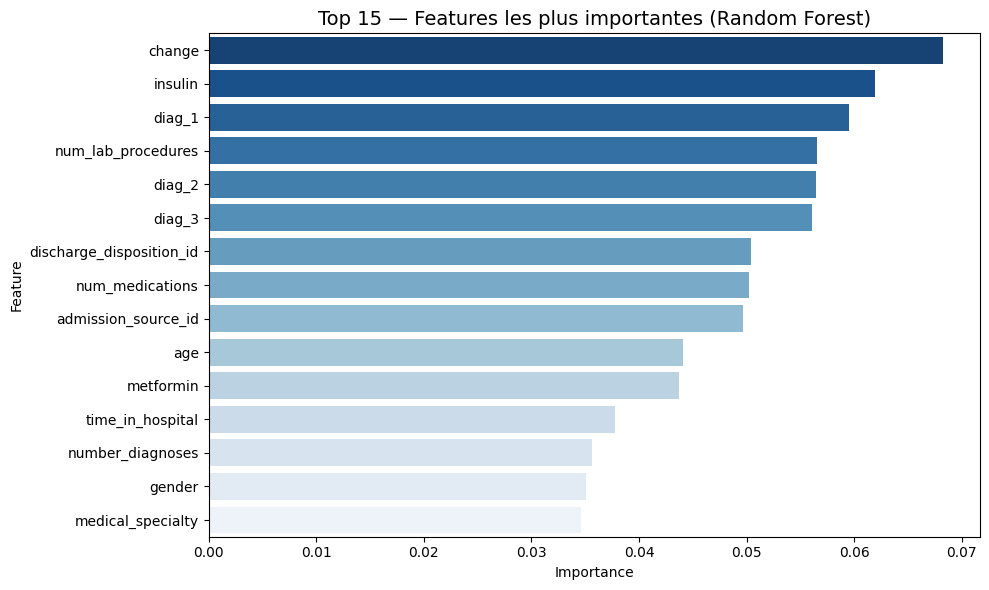


Top 10 features :
                 feature  importance
                  change    0.068279
                 insulin    0.061888
                  diag_1    0.059472
      num_lab_procedures    0.056529
                  diag_2    0.056411
                  diag_3    0.056124
discharge_disposition_id    0.050415
         num_medications    0.050245
     admission_source_id    0.049647
                     age    0.044066

✅ Graphique sauvegardé !


In [6]:
print("="*50)
print("IMPORTANCE DES FEATURES — RANDOM FOREST")
print("="*50)

# Top 15 features les plus importantes
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': results['Random Forest']['model'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance,
    hue='feature',
    palette='Blues_r',
    legend=False
)
plt.title('Top 15 — Features les plus importantes (Random Forest)', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features :")
print(feature_importance.head(10).to_string(index=False))
print("\n✅ Graphique sauvegardé !")

INTERPRÉTABILITÉ — SHAP VALUES


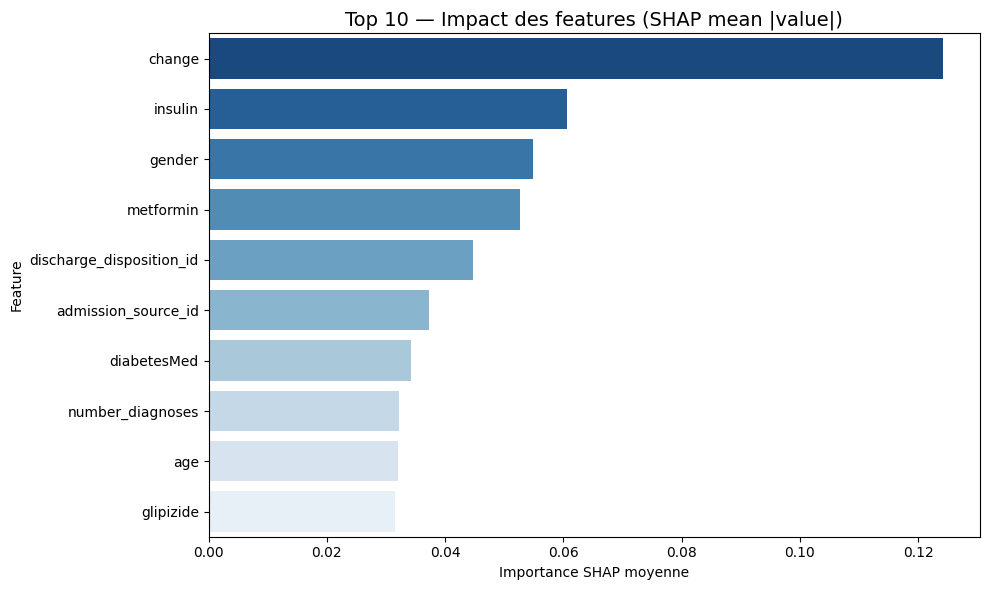

✅ Graphique SHAP sauvegardé !


In [8]:
print("="*50)
print("INTERPRÉTABILITÉ — SHAP VALUES")
print("="*50)

import shap

X_sample = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(results['Random Forest']['model'])
shap_values = explainer.shap_values(X_sample)

# Gestion de toutes les formes possibles
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Calcul des importances SHAP
mean_shap = np.abs(sv).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': mean_shap.tolist()
}).sort_values('importance', ascending=False).head(10)

# Graphique
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=shap_importance,
    hue='feature',
    palette='Blues_r',
    legend=False,
    ax=ax
)
ax.set_title('Top 10 — Impact des features (SHAP mean |value|)', fontsize=14)
ax.set_xlabel('Importance SHAP moyenne')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/shap_values.png', dpi=150)
plt.show()
print("✅ Graphique SHAP sauvegardé !")